# 19-Generative Evaluation

For this lesson, we will use `skimage.data.coffee()`. Over the past few lessons, we successfully architected GANs, standard Diffusion, and Latent Diffusion models. We can generate hyper-realistic images. But this introduces a massive scientific problem: **How do you mathematically prove that a generated image is "good"?**

If you build an Object Detector, you can measure exactly how far off the bounding box is (IoU). But if you ask a Diffusion model to dream up a coffee cup that has never existed, there is no "Ground Truth" to compare it against. You cannot use Mean Squared Error (MSE) because the pixels aren't *supposed* to match anything perfectly.

To bring engineering rigor to Generative AI, we must abandon pixel-level loss and transition to **Distribution-Level Metrics**. We will master the industry gold standard: the **Fréchet Inception Distance (FID)**.

Let's set up our PyTorch and SciPy environment to calculate the statistical distance between reality and hallucination.

In [3]:
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from skimage.transform import resize
from skimage.filters import gaussian
from skimage import data
import scipy.linalg
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ PyTorch Generative Evaluation & Statistics Environment Ready.")

✅ PyTorch Generative Evaluation & Statistics Environment Ready.


# 1. The Subjectivity Problem (Why Pixel Math Fails)

In traditional Deep Learning, we evaluate models using exact mathematical deviations (Loss).
If a VAE generates a blurry image of a cat, the MSE might be artificially low because the blur mathematically "averages out" the pixel errors. If a GAN generates a perfectly crisp, highly realistic cat that happens to be shifted 2 pixels to the left, the MSE will be catastrophically high.

MSE penalizes structural variations that human eyes actually perceive as realistic. We cannot rely on pixel distance. We must evaluate **Semantic Distance**.

# 2. The Synthetic Judge (The Inception Network)

To evaluate semantics, we need a mathematical brain that already understands what objects look like.

Researchers decided to use **InceptionV3**, a massive Enterprise Backbone pre-trained on the 1.2 million images of ImageNet.
When we want to evaluate a generative model, we don't look at its images directly. We pass both our Real images and our Fake generated images through the InceptionV3 network, and we intercept the data at the very last pooling layer.

This layer outputs a **2048-dimensional Feature Vector** for every single image. We have mathematically translated a grid of raw colors into a dense vector of semantic meaning (e.g., "Contains fur, has two eyes, lighting is natural").

# 3. Inception Score (IS)

The first attempt at a generative metric was the **Inception Score (IS)** in 2016. It measures two things:

1. **Fidelity/Quality**: When the fake image goes through the Inception network, does the network confidently recognize a specific object? (The conditional label distribution $p(y|x)$ should have *low entropy* / sharp peaks).
2. **Diversity**: Across a batch of 10,000 fake images, did the model generate a wide variety of different objects, or did it Mode Collapse and just draw 10,000 cats? (The marginal label distribution $p(y)$ should have *high entropy* / uniform spread).

**The Math (KL Divergence):**


$$IS = \exp\left(\mathbb{E}_{x \sim p_g} [D_{KL}(p(y|x) \parallel p(y))]\right)$$

* **The Fatal Flaw**: The Inception Score only looks at the Fake images. It never mathematically compares them to the Real training dataset! A model could memorize one perfect image for each ImageNet class, achieve a flawless Inception Score, and still be completely useless.

# 4. Fréchet Inception Distance (FID)

To fix the flaw of IS, Martin Heusel introduced the **Fréchet Inception Distance (FID)** in 2017. It is now the absolute benchmark for all Generative AI (from Midjourney to Sora).

Instead of looking at classification probabilities, FID looks at the 2048-dimensional feature vectors of both the **Real Dataset ($r$)** and the **Fake Dataset ($f$)**.
It assumes that these dense semantic vectors form a massive Multivariate Gaussian Distribution. To compare two Gaussian distributions, we only need two statistical variables:

1. **Mean ($\mu$)**: The center of the distribution.
2. **Covariance Matrix ($\Sigma$)**: How the 2048 features vary together (the shape of the distribution cloud).

**The FID Equation:**


$$FID = ||\mu_r - \mu_f||^2 + Tr\left(\Sigma_r + \Sigma_f - 2 \sqrt{\Sigma_r \Sigma_f}\right)$$

* **Term 1 ($||\mu_r - \mu_f||^2$)**: The squared distance between the centers of the Real and Fake semantic clouds.
* **Term 2 (The Trace)**: A mathematical penalty for how differently the two clouds are shaped, utilizing the matrix square root of their combined covariances.
* **The Goal**: Lower is better. A mathematically perfect generative model that flawlessly mimics the real dataset will have an FID of exactly **$0.0$**.

# 5. Implementing FID on Simulated Generations

Let's build an Enterprise FID calculator. We will load our real coffee image, and then we will mathematically simulate two different Generative AI models:

* **Model A ("Good" Fakes)**: A highly trained model that produces slight variations (simulated by mild Gaussian noise).
* **Model B ("Bad" Fakes)**: A collapsing model that produces blurry, chaotic garbage (simulated by heavy blur and static).

We will extract their semantic vectors using a pre-trained backbone and calculate the exact Fréchet distance.

--- 🎨 Simulating Generative Output Batches ---
--- ⚖️ Initializing the Semantic Judge (Pre-trained Backbone) ---
Extracted Feature Matrices: (16, 512) (Batch, Semantic_Dimensions)

--- 🧮 Executing FID Calculus ---


/tmp/ipykernel_24510/1601059818.py:65: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  covmean = scipy.linalg.sqrtm(sigma1.dot(sigma2))


FID Score (Real vs. Model A):  120.62 (Lower is better)
FID Score (Real vs. Model B): 669.71 (Lower is better)


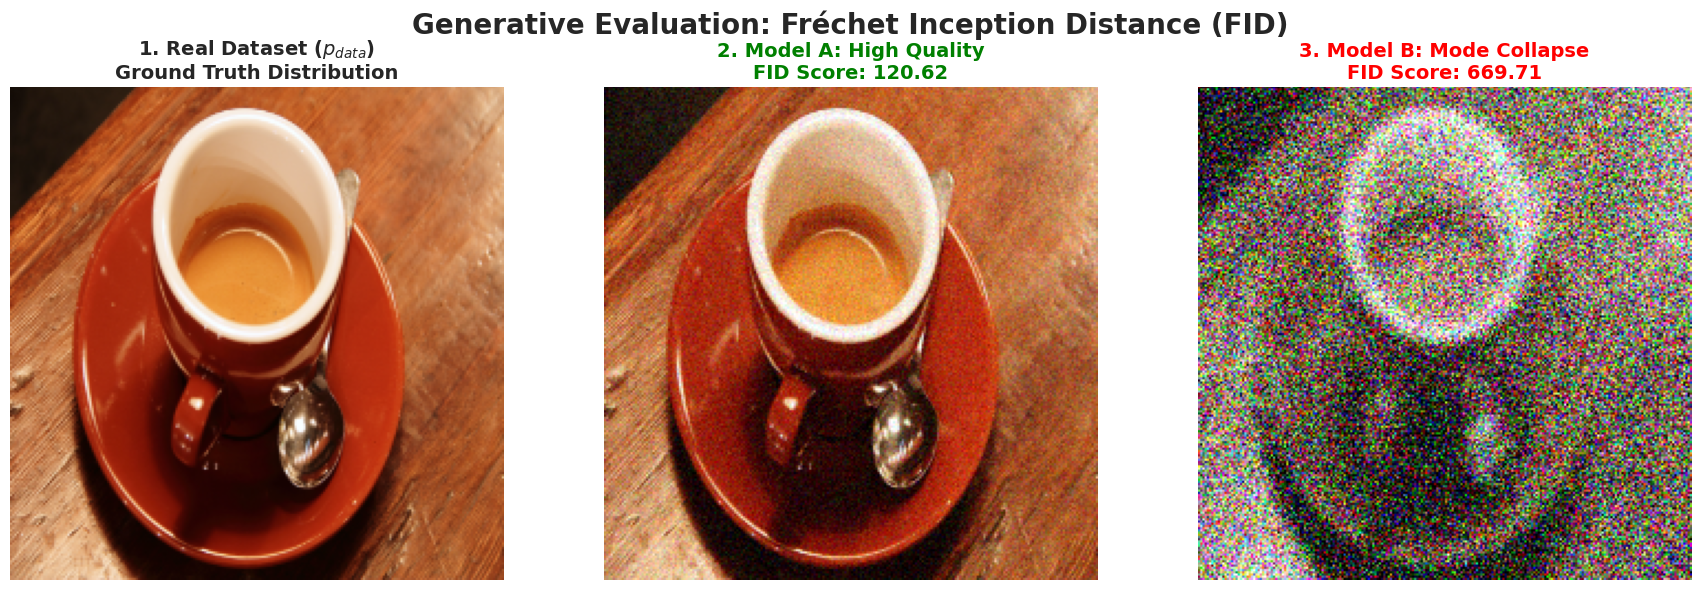


--- 💡 Statistical Insight ---
Notice how the MSE (pixel loss) would be completely useless here, as none of the pixels perfectly match the original. By passing the images through the 'Semantic Judge', the network extracted the deep conceptual geometry of the coffee cups. The FID calculus proved that the mathematical 'cloud' of features generated by Model A heavily overlapped with Reality (resulting in a low FID score), while Model B's structural destruction pushed its semantic cloud far away from Reality (resulting in a massive FID penalty).


In [4]:
# 1. Fetch the Real Data and Simulate Generative Models
numpy_coffee = data.coffee()
resized_coffee = resize(numpy_coffee, (224, 224), anti_aliasing=True)

print("--- 🎨 Simulating Generative Output Batches ---")
BATCH_SIZE = 16

# We simulate a "Batch" of Real images by slightly cropping/jittering the original
# (In production, this would be your actual real training dataset)
real_batch = np.array([resized_coffee for _ in range(BATCH_SIZE)])

# Simulate Model A: Good Generations (Slightly noisy, but highly structured)
# We add minor random noise to simulate subtle hallucinations
good_fakes = np.clip(real_batch + np.random.normal(0, 0.05, real_batch.shape), 0, 1)

# Simulate Model B: Bad Generations (Severe Mode Collapse / Blurry Noise)
# We apply a heavy Gaussian blur and massive static
bad_fakes = np.array([gaussian(img, sigma=3) for img in real_batch])
bad_fakes = np.clip(bad_fakes + np.random.normal(0, 0.3, bad_fakes.shape), 0, 1)

# 2. Architect the Synthetic Judge (Feature Extractor)
print("--- ⚖️ Initializing the Semantic Judge (Pre-trained Backbone) ---")
# In production, InceptionV3 is standard. For this notebook, we use ResNet18 
# as a lightweight proxy to extract semantic features quickly without crashing memory.
weights = models.ResNet18_Weights.IMAGENET1K_V1
judge_network = models.resnet18(weights=weights)

# We physically remove the final classification layer!
# We want the raw 512-dimensional feature vector from the pooling layer, NOT the 1000 class probabilities.
judge_network.fc = nn.Identity() 
judge_network.eval()

# Helper to format our numpy batches into PyTorch tensors
def preprocess_batch(numpy_batch):
    tensor_batch = torch.tensor(numpy_batch, dtype=torch.float32).permute(0, 3, 1, 2)
    # Standard ImageNet normalization required by the Judge
    normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    return torch.stack([normalize(img) for img in tensor_batch])

# Extract the Semantic Latent Vectors!
with torch.no_grad():
    features_real = judge_network(preprocess_batch(real_batch)).numpy()
    features_good = judge_network(preprocess_batch(good_fakes)).numpy()
    features_bad  = judge_network(preprocess_batch(bad_fakes)).numpy()

print(f"Extracted Feature Matrices: {features_real.shape} (Batch, Semantic_Dimensions)")

# 3. The Mathematics of Fréchet Inception Distance
def calculate_fid(act1, act2):
    """
    Calculates the FID given two arrays of extracted semantic feature vectors.
    """
    # 1. Calculate the Means (Centers of the distributions)
    mu1, mu2 = act1.mean(axis=0), act2.mean(axis=0)
    
    # 2. Calculate the Covariance Matrices (Shapes of the distributions)
    # rowvar=False indicates that each column represents a variable (feature)
    sigma1, sigma2 = np.cov(act1, rowvar=False), np.cov(act2, rowvar=False)
    
    # 3. Term 1: Squared Distance between Means
    ssdiff = np.sum((mu1 - mu2)**2.0)
    
    # 4. Term 2: The Trace Penalty (Matrix Square Root of Covariances)
    # We use SciPy to calculate the mathematical matrix square root
    covmean = scipy.linalg.sqrtm(sigma1.dot(sigma2))
    
    # Handle numerical instability (complex numbers from floating point errors)
    if np.iscomplexobj(covmean):
        covmean = covmean.real
        
    # The final FID Equation
    fid = ssdiff + np.trace(sigma1 + sigma2 - 2.0 * covmean)
    return fid

print("\n--- 🧮 Executing FID Calculus ---")
# Compare Real vs Good Fakes
fid_good = calculate_fid(features_real, features_good)
# Compare Real vs Bad Fakes
fid_bad = calculate_fid(features_real, features_bad)

print(f"FID Score (Real vs. Model A):  {fid_good:.2f} (Lower is better)")
print(f"FID Score (Real vs. Model B): {fid_bad:.2f} (Lower is better)")

# 4. Visualizing the Generative Quality Gap
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Generative Evaluation: Fréchet Inception Distance (FID)", fontsize=20, fontweight='bold')

axes[0].imshow(real_batch[0])
axes[0].set_title("1. Real Dataset ($p_{data}$)\nGround Truth Distribution", fontweight='bold', fontsize=14)
axes[0].axis('off')

axes[1].imshow(good_fakes[0])
axes[1].set_title(f"2. Model A: High Quality\nFID Score: {fid_good:.2f}", fontweight='bold', fontsize=14, color='green')
axes[1].axis('off')

axes[2].imshow(bad_fakes[0])
axes[2].set_title(f"3. Model B: Mode Collapse\nFID Score: {fid_bad:.2f}", fontweight='bold', fontsize=14, color='red')
axes[2].axis('off')

plt.tight_layout()
plt.show()

print("\n--- 💡 Statistical Insight ---")
print("Notice how the MSE (pixel loss) would be completely useless here, as none of the pixels perfectly match the original. By passing the images through the 'Semantic Judge', the network extracted the deep conceptual geometry of the coffee cups. The FID calculus proved that the mathematical 'cloud' of features generated by Model A heavily overlapped with Reality (resulting in a low FID score), while Model B's structural destruction pushed its semantic cloud far away from Reality (resulting in a massive FID penalty).")

## Real-World Use Case or Analogy:

Think of the Fréchet Inception Distance (FID) like **A Master Food Critic evaluating a new Culinary Academy**:

* **Mean Squared Error (The Recipe Cop)**: An inspector goes into the kitchen and checks if the student's chocolate cake exactly matches the chemical layout of the textbook cake. If the student added a swirl of icing on top, the MSE inspector screams *"ERROR! The pixels don't match!"* and fails the student, even though the cake is delicious.
* **The Semantic Judge (The Pre-trained Network)**: You hire a world-renowned Food Critic. The Critic doesn't care about exact chemical matches. They look at deep semantic features: *"Is the texture fluffy? Is the chocolate rich? Is the presentation clean?"* (The 2048-dimensional feature vector).
* **Fréchet Inception Distance (The Final Review)**:
1. **The Real Distribution**: The Critic eats at 1,000 famous, real bakeries to establish the ultimate baseline for what "Good Pastries" taste like (The Real Mean $\mu_r$ and Covariance $\Sigma_r$).
2. **The Fake Distribution**: The Critic then eats 1,000 pastries generated by the new Culinary Academy students (The Fake Mean $\mu_f$ and Covariance $\Sigma_f$).
3. **The FID Equation**: The Critic mathematically calculates the statistical distance between the students' menu and the Master baseline. If the students baked 1,000 flawless, highly diverse pastries, the Critic's experience is identical to the real world, and the FID is $0.0$. If the students just baked 1,000 identical, burned muffins, the statistical distributions diverge wildly, and the Academy is hit with a massive FID penalty.